# KleinVAE experiments

This notebook contains the full Klein-Circles experiment: data generation,
model training, best-checkpoint selection, evaluation, persistence-diagram
metrics, and the paper figures.

KleinVAE, TorusVAE, and Euclidean VAE are trained and evaluated with seed 28.
No seed sweep is run.


In [1]:
from datetime import datetime
from pathlib import Path
import json
import os
import subprocess
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import Image, display

ROOT = next(
    candidate for candidate in (Path.cwd(), *Path.cwd().parents)
    if (candidate / '.project-root').exists()
)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

TRAINING_SEED = 28
EVALUATION_SEED = TRAINING_SEED
RESULTS = ROOT / 'results' / 'klein_circles'
RESULTS_FILE = RESULTS / 'results.csv'
FIGURE = RESULTS / 'comparison.png'
TRAINING_CURVES = RESULTS / 'training_curves.png'
RUN_ID = os.environ.get('KLEINVAE_RUN_ID', datetime.now().strftime('%Y%m%d_%H%M%S'))
RUN_ROOT = ROOT / 'logs' / f'klein_circles_seed{TRAINING_SEED}' / RUN_ID
RESULTS.mkdir(parents=True, exist_ok=True)

torch.manual_seed(TRAINING_SEED)
np.random.seed(TRAINING_SEED)
print(f'Seed: {TRAINING_SEED}')


Seed: 28


## Experiment configuration

- **Data:** 100,000 binary 30×30 Klein-Circles images with radius 0.3 and an
  80/10/10 train/validation/test split.
- **Models:** KleinVAE, TorusVAE, and Euclidean VAE with the same
  `900 → 1024 → 512 → 128 → 32 → 5` encoder, reversed decoder, two-dimensional
  latent space, and full 2×2 posterior covariance.
- **Training:** seed 28, 50 epochs, Adam at `1e-3`, batch size 1024,
  pixel-summed Bernoulli reconstruction NLL, and KL weight 1.
- **Selection:** lowest-validation-loss checkpoint for each model.
- **Evaluation:** the generated test dataset uses seed 28 and 10,000 observations;
  persistent homology uses 400 observations.
- **Topology:** mean H1/H2 bottleneck distance over Z2 and Z3. Input and latent
  distance matrices are normalized by their 90th-percentile nonzero distance.

The Hydra configuration is `configs/experiment/klein_circles.yaml`.


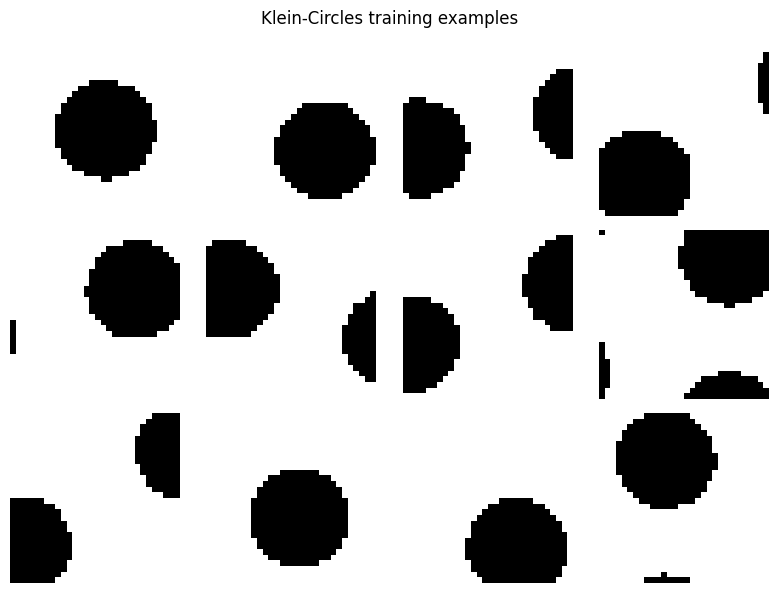

In [2]:
from src.data.circles_datamodule import CirclesDatamodule

preview_dm = CirclesDatamodule(
    image_linear_pixel_size=30,
    circle_radius=0.3,
    num_images=256,
    batch_size=64,
    persistence_subsample_size=32,
    seed=TRAINING_SEED,
)
preview_dm.setup()
preview = torch.stack([preview_dm.train_dataset[i][0] for i in range(12)])

fig, axes = plt.subplots(3, 4, figsize=(8, 6))
for image, axis in zip(preview, axes.flat, strict=True):
    axis.imshow(image.reshape(30, 30), cmap='gray_r')
    axis.axis('off')
fig.suptitle('Klein-Circles training examples')
fig.tight_layout()
data_figure = RESULTS / 'data_examples.png'
fig.savefig(data_figure, dpi=180, bbox_inches='tight')
plt.show()


## Train the models

Set `KLEINVAE_RUN_TRAINING=1` before executing the notebook to run training.
Each model writes its resolved configuration, epoch-level CSV metrics, last
checkpoint, and best-validation checkpoint below `logs/klein_circles_seed28/`.

The CSV logs contain reconstruction NLL, KL, negative ELBO, posterior log
variance, empirical latent-code variance, and log empirical latent-code
variance.


In [3]:
RUN_TRAINING = os.environ.get('KLEINVAE_RUN_TRAINING', '0') == '1'
MODEL_CONFIGS = {
    'klein': 'klein_vae',
    'torus': 'torus_vae',
    'euclidean': 'vanilla_vae',
}
CHECKPOINTS = {}

if RUN_TRAINING:
    for model_kind, model_config in MODEL_CONFIGS.items():
        run_dir = RUN_ROOT / model_kind
        command = [
            'uv', 'run', 'python', 'main.py',
            'experiment=klein_circles',
            f'model={model_config}',
            f'seed={TRAINING_SEED}',
            f'data.seed={TRAINING_SEED}',
            f'hydra.run.dir={run_dir}',
            'callbacks.topology_metrics.input_metric=intrinsic_klein',
            'extras.print_config=False',
        ]
        print(' '.join(map(str, command)))
        subprocess.run(command, cwd=ROOT, check=True)

        candidates = sorted((run_dir / 'checkpoints').glob('epoch_*.ckpt'))
        if len(candidates) != 1:
            raise RuntimeError(
                f'Expected one best checkpoint for {model_kind}, found {candidates}'
            )
        CHECKPOINTS[model_kind] = candidates[0]
        print(f'{model_kind}: {candidates[0]}')
else:
    print('Using saved results. Set KLEINVAE_RUN_TRAINING=1 to train the models.')


Using saved results. Set KLEINVAE_RUN_TRAINING=1 to train the models.


## Evaluate the best checkpoints

Reconstruction NLL uses posterior-mean reconstructions. Negative ELBO and
empirical latent-code variance use one reproducible posterior sample. Input
persistence uses the generating Klein coordinates; each latent uses its native
metric.


In [4]:
RUN_EVALUATION = (
    RUN_TRAINING
    or os.environ.get('KLEINVAE_RUN_EVALUATION', '0') == '1'
)
raw_dir = RESULTS / 'raw'

if RUN_EVALUATION:
    if not CHECKPOINTS:
        for model_kind in MODEL_CONFIGS:
            candidates = sorted(
                (RUN_ROOT / model_kind / 'checkpoints').glob('epoch_*.ckpt')
            )
            if len(candidates) != 1:
                raise RuntimeError(
                    f'Expected one saved checkpoint for {model_kind} under '
                    f'{RUN_ROOT}, found {candidates}'
                )
            CHECKPOINTS[model_kind] = candidates[0]
    raw_dir.mkdir(parents=True, exist_ok=True)
    for model_kind, checkpoint in CHECKPOINTS.items():
        output = raw_dir / f'seed{TRAINING_SEED}_{model_kind}.json'
        subprocess.run(
            [
                'uv', 'run', 'python', 'scripts/evaluate_checkpoint.py',
                str(checkpoint),
                '--model-kind', model_kind,
                '--covariance-type', 'full',
                '--split', 'test',
                '--data-seed', str(EVALUATION_SEED),
                '--intrinsic-input-metric',
                '--persistence-sample-size', '400',
                '--output', str(output),
            ],
            cwd=ROOT,
            check=True,
        )
else:
    print('Using the saved single-run evaluation.')


Using the saved single-run evaluation.


In [5]:
if RUN_EVALUATION:
    records = []
    for model_kind in MODEL_CONFIGS:
        record = json.loads((raw_dir / f'seed{TRAINING_SEED}_{model_kind}.json').read_text())
        record['training_seed'] = TRAINING_SEED
        record['evaluation_seed'] = EVALUATION_SEED
        records.append(record)
    results = pd.DataFrame(records)
    columns = [
        'training_seed', 'evaluation_seed', 'model_kind', 'recon_nll',
        'negative_elbo', 'posterior_log_variance',
        'empirical_latent_code_variance', 'log_empirical_latent_code_variance',
        'latent_topology_score', 'latent_bottleneck_z2_h1',
        'latent_bottleneck_z2_h2', 'latent_bottleneck_z3_h1',
        'latent_bottleneck_z3_h2',
    ]
    results = results[columns].rename(columns={'model_kind': 'model'})
    results.to_csv(RESULTS_FILE, index=False)
else:
    results = pd.read_csv(RESULTS_FILE)

model_names = {
    'klein': 'KleinVAE',
    'torus': 'TorusVAE',
    'euclidean': 'Euclidean VAE',
}
table = results.copy()
table['model'] = table['model'].map(model_names)
display(table[[
    'model', 'recon_nll', 'negative_elbo', 'latent_topology_score',
    'posterior_log_variance', 'empirical_latent_code_variance',
]].rename(columns={
    'model': 'Model',
    'recon_nll': 'Reconstruction NLL',
    'negative_elbo': 'Negative ELBO / bound',
    'latent_topology_score': 'H1/H2 bottleneck',
    'posterior_log_variance': 'Posterior log variance',
    'empirical_latent_code_variance': 'Empirical latent variance',
}).round(4))


,Model,Reconstruction NLL,Negative ELBO / bound,H1/H2 bottleneck,Posterior log variance,Empirical latent variance
0,KleinVAE,62.2212,76.6801,0.1261,-11.9230,0.1576
1,TorusVAE,121.0282,132.6084,0.1455,-10.6128,0.3019
2,Euclidean VAE,20.4626,31.9845,0.1876,-9.0044,4.1845


## Results

| Model | Reconstruction NLL | Negative ELBO / bound | H1/H2 bottleneck | Log empirical latent variance |
|---|---:|---:|---:|---:|
| KleinVAE | 62.22 | 76.68 | 0.1261 | -1.8478 |
| TorusVAE | 121.03 | 132.61 | 0.1455 | -1.1975 |
| Euclidean VAE | 20.46 | 31.98 | 0.1876 | 1.4314 |


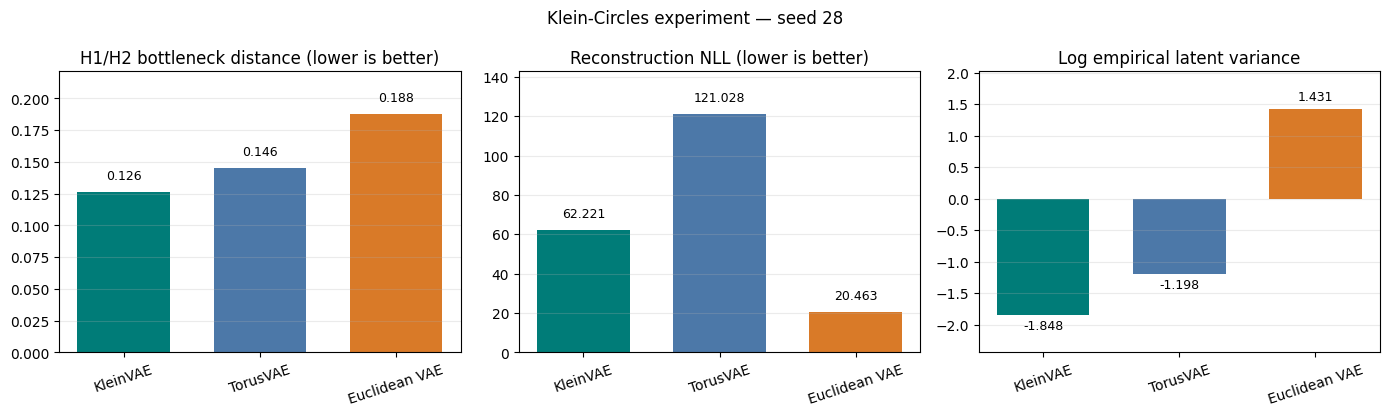

In [6]:
order = ['klein', 'torus', 'euclidean']
labels = ['KleinVAE', 'TorusVAE', 'Euclidean VAE']
colors = ['#007C78', '#4C78A8', '#D97A28']
plot_data = results.set_index('model').loc[order]

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
panels = [
    ('latent_topology_score', 'H1/H2 bottleneck distance (lower is better)'),
    ('recon_nll', 'Reconstruction NLL (lower is better)'),
    ('log_empirical_latent_code_variance', 'Log empirical latent variance'),
]
for axis, (column, title) in zip(axes, panels, strict=True):
    bars = axis.bar(labels, plot_data[column], color=colors, width=0.68)
    axis.set_title(title)
    axis.tick_params(axis='x', rotation=18)
    axis.grid(axis='y', alpha=0.25)
    padding = max(plot_data[column].abs().max() * 0.04, 0.002)
    for bar, value in zip(bars, plot_data[column], strict=True):
        axis.text(
            bar.get_x() + bar.get_width() / 2,
            value + (padding if value >= 0 else -padding),
            f'{value:.3f}',
            ha='center',
            va='bottom' if value >= 0 else 'top',
            fontsize=9,
        )
    axis.margins(y=0.18)
fig.suptitle(f'Klein-Circles experiment — seed {TRAINING_SEED}')
fig.tight_layout()
fig.savefig(FIGURE, dpi=200, bbox_inches='tight')
plt.show()


In [7]:
indexed = results.set_index('model')
assert indexed.loc['klein', 'latent_topology_score'] < indexed.loc['euclidean', 'latent_topology_score']
assert indexed.loc['klein', 'recon_nll'] > indexed.loc['euclidean', 'recon_nll']

topology_reduction = 1 - (
    indexed.loc['klein', 'latent_topology_score'] /
    indexed.loc['euclidean', 'latent_topology_score']
)
print(f'KleinVAE topology-score reduction vs Euclidean VAE: {topology_reduction:.1%}')
print(
    f"Reconstruction NLL: KleinVAE={indexed.loc['klein', 'recon_nll']:.2f}, "
    f"Euclidean VAE={indexed.loc['euclidean', 'recon_nll']:.2f}"
)


KleinVAE topology-score reduction vs Euclidean VAE: 32.8%
Reconstruction NLL: KleinVAE=62.22, Euclidean VAE=20.46


KleinVAE reduces the intrinsic topology score by 32.8% relative to the
Euclidean VAE in this run. The Euclidean VAE has the lower reconstruction NLL.
KleinVAE and TorusVAE give similar topology scores, while KleinVAE reconstructs
substantially better than TorusVAE.

### Logged quantities

| Name | Definition |
|---|---|
| `recon_nll` | Pixel-summed Bernoulli negative log-likelihood per observation. |
| `kl` | Gaussian KL for Euclidean VAE; cover-space KL bound for KleinVAE/TorusVAE. |
| `negative_elbo` | Posterior reconstruction estimate plus KL. |
| `posterior_log_variance` | Mean `log(diag(Σq(x)))` produced by the encoder. |
| `latent_code_variance` | Sum of coordinate variances of projected posterior samples. |
| `log_latent_code_variance` | Natural logarithm of empirical latent-code variance. |
| `latent_topology_score` | Mean H1/H2 bottleneck distance over Z2 and Z3. |


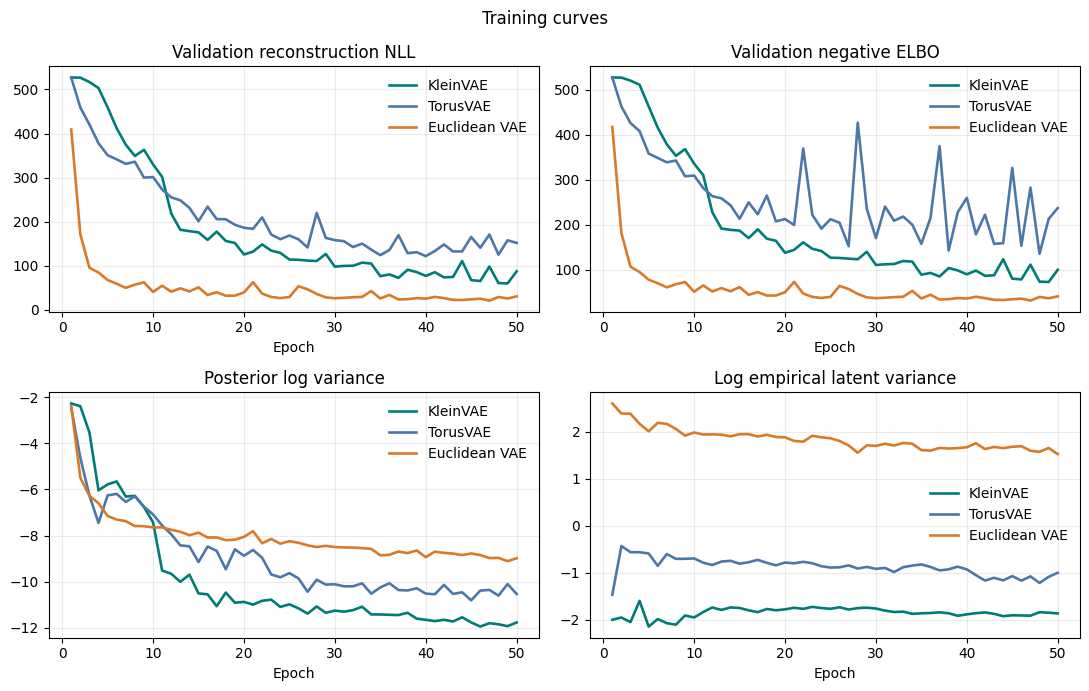

In [8]:
history_paths = {
    model_kind: RUN_ROOT / model_kind / 'csv' / 'version_0' / 'metrics.csv'
    for model_kind in MODEL_CONFIGS
}
if all(path.exists() for path in history_paths.values()):
    metric_titles = {
        'val_recon_nll': 'Validation reconstruction NLL',
        'val_negative_elbo': 'Validation negative ELBO',
        'val_posterior_log_variance': 'Posterior log variance',
        'log_latent_code_variance': 'Log empirical latent variance',
    }
    model_colors = {'klein': '#007C78', 'torus': '#4C78A8', 'euclidean': '#D97A28'}
    fig, axes = plt.subplots(2, 2, figsize=(11, 7))
    for model_kind in MODEL_CONFIGS:
        metrics_path = history_paths[model_kind]
        history = pd.read_csv(metrics_path)
        for axis, (metric, title) in zip(axes.flat, metric_titles.items(), strict=True):
            curve = history[['epoch', metric]].dropna().groupby('epoch')[metric].last()
            axis.plot(
                curve.index + 1, curve.values, label=model_names[model_kind],
                color=model_colors[model_kind], linewidth=1.9,
            )
            axis.set_title(title)
            axis.set_xlabel('Epoch')
            axis.grid(alpha=0.25)
    for axis in axes.flat:
        axis.legend(frameon=False)
    fig.suptitle('Training curves')
    fig.tight_layout()
    fig.savefig(TRAINING_CURVES, dpi=180, bbox_inches='tight')
    plt.show()
else:
    print(
        'Training history not found for this run ID. Set KLEINVAE_RUN_TRAINING=1 '
        'to train the models or KLEINVAE_RUN_ID to an existing run.'
    )


## Appendix figures

The following cell regenerates Figures 5 and 6 from the exported curves in
`data/appendix/`.


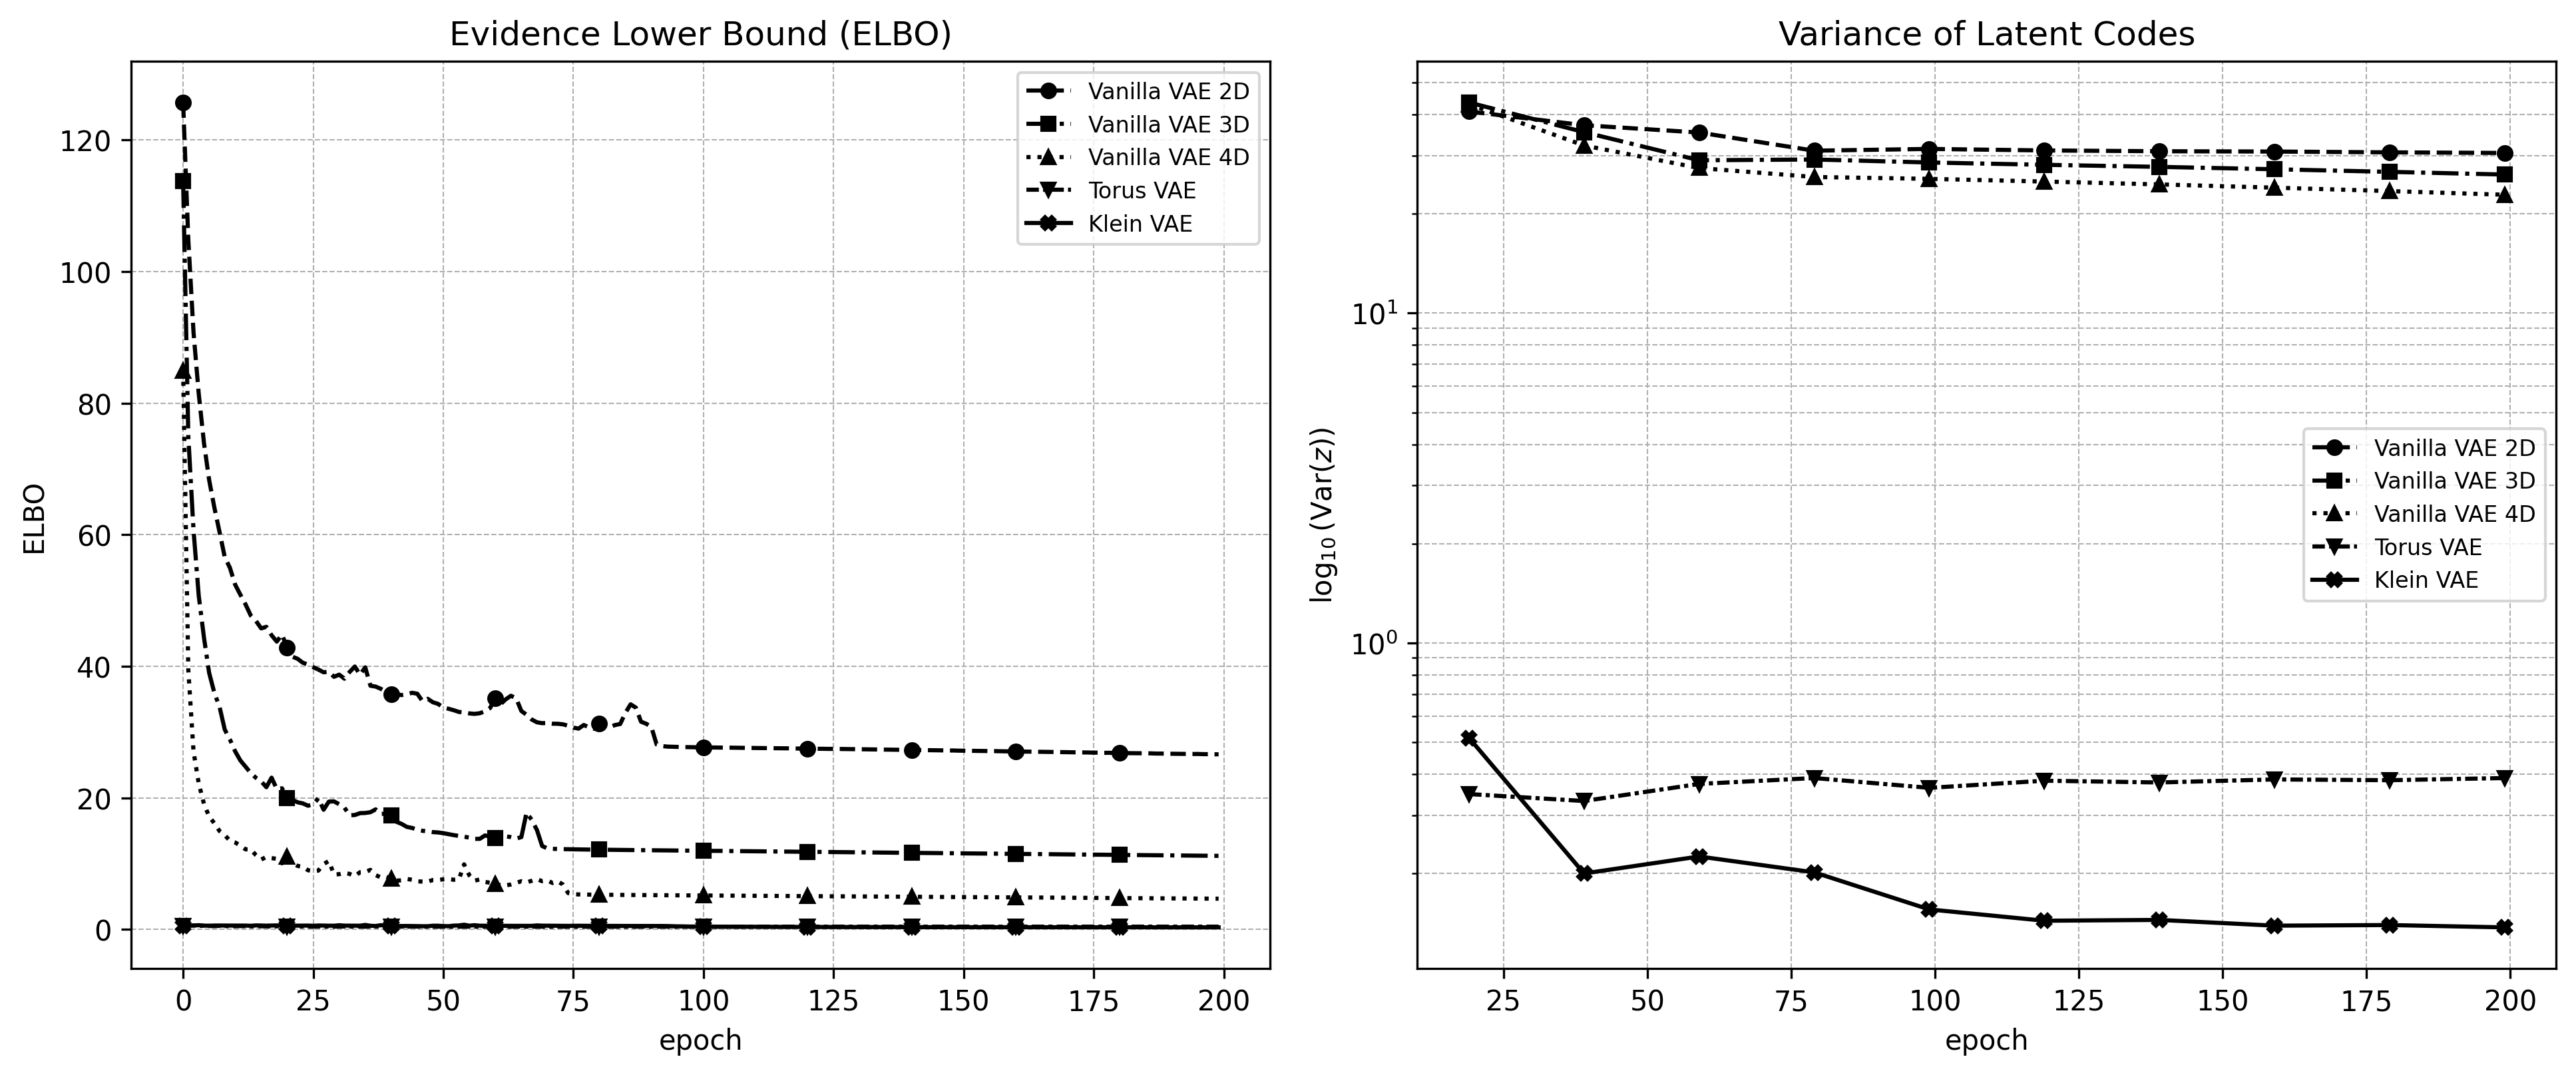

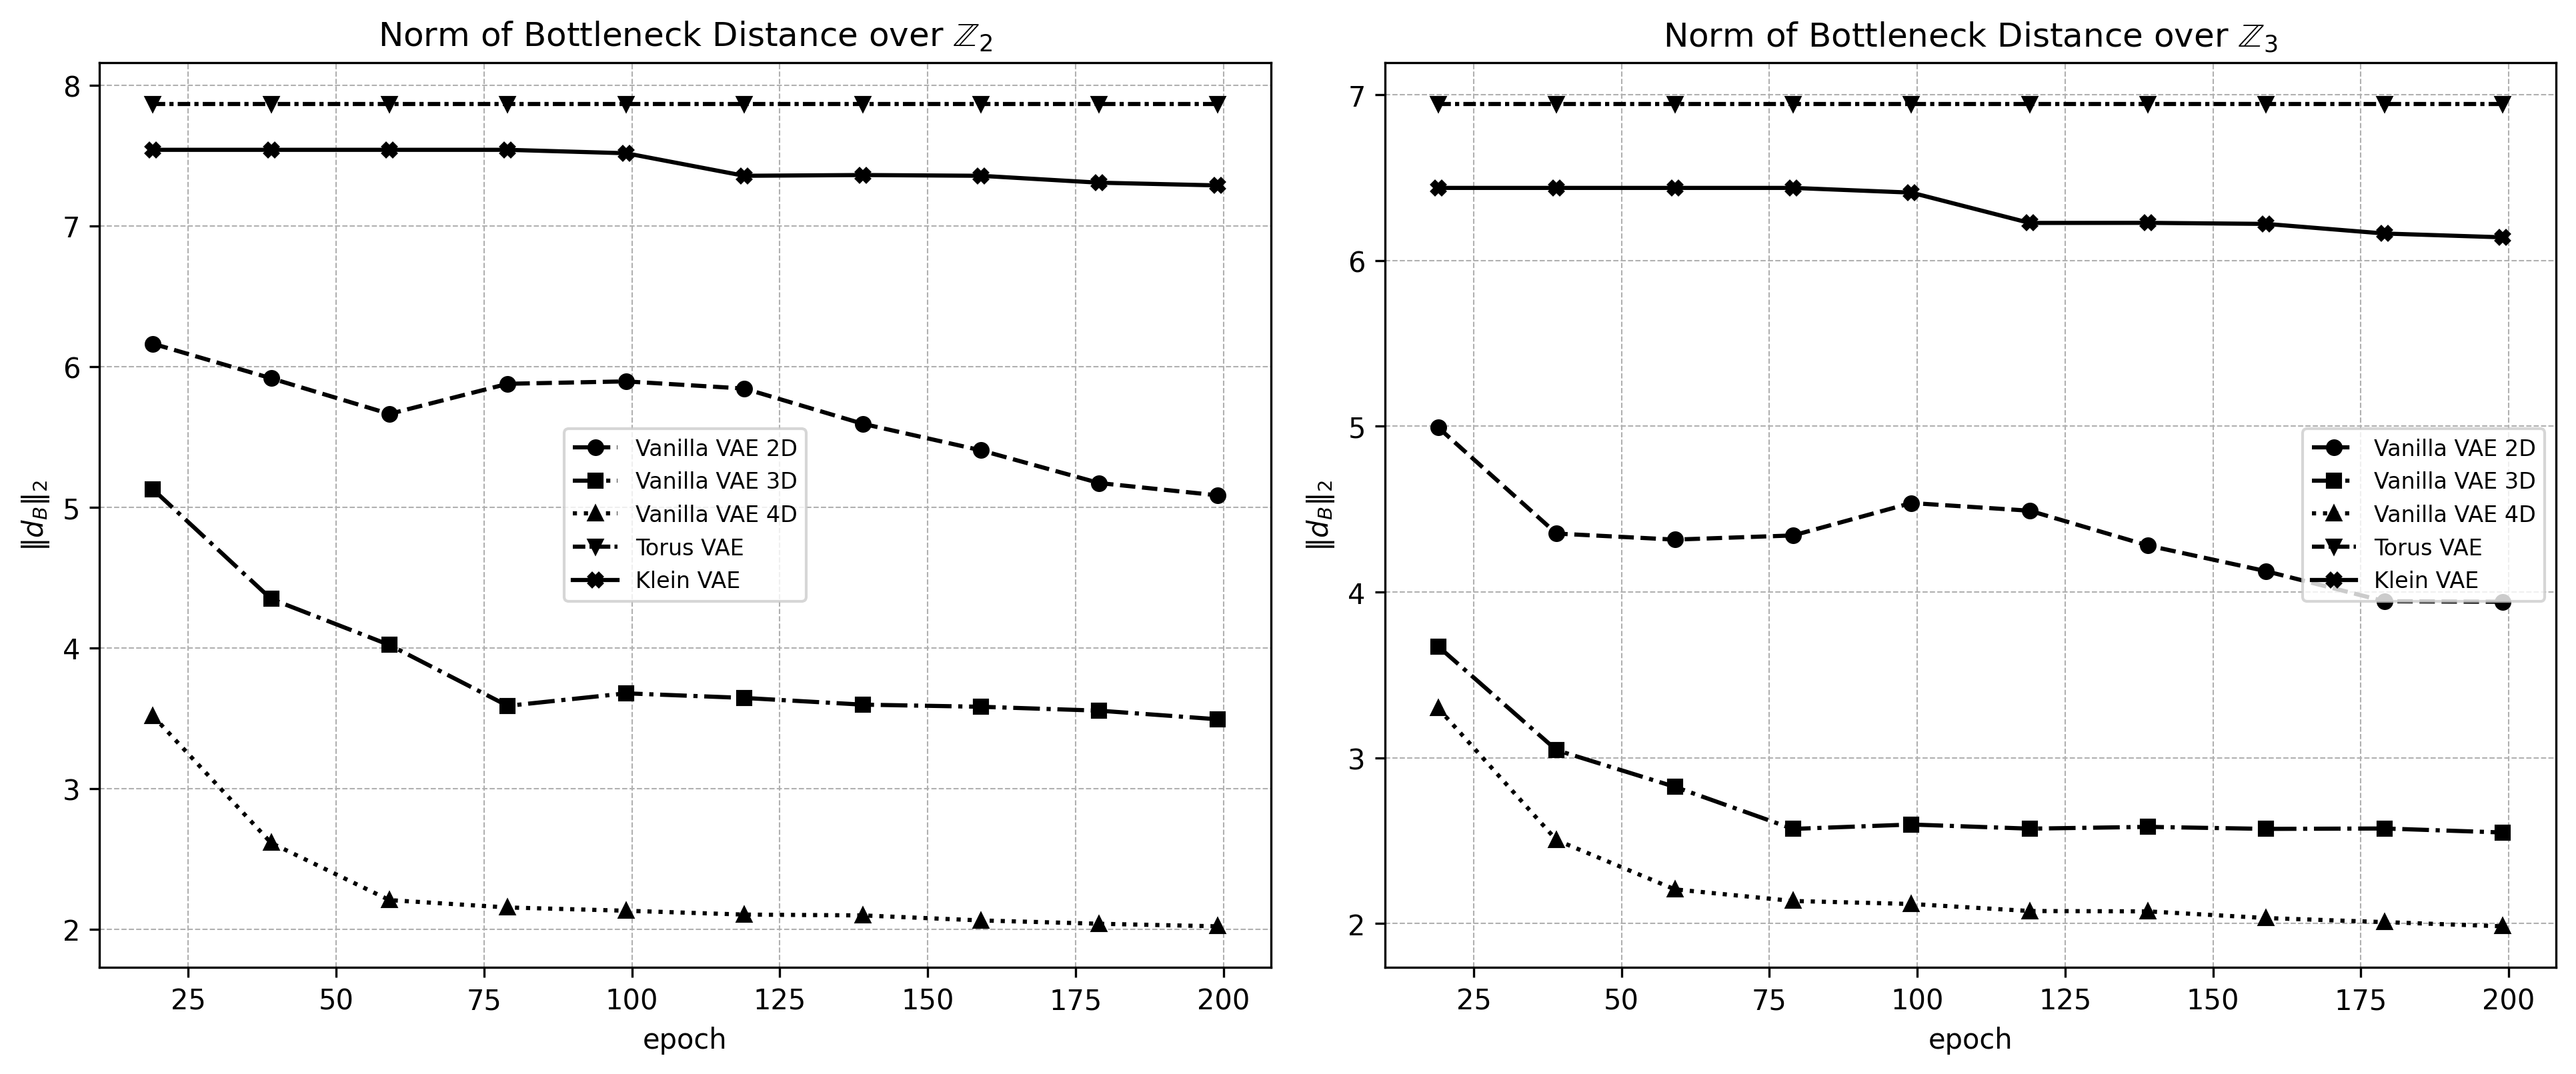

In [9]:
from scripts.plot_appendix import generate_figures

appendix_outputs = generate_figures(ROOT / 'results' / 'appendix')
display(Image(filename=str(appendix_outputs['figure5'])))
display(Image(filename=str(appendix_outputs['figure6'])))


![Appendix Figure 5](../results/appendix/figure5.png)

![Appendix Figure 6](../results/appendix/figure6.png)

## Files

- `configs/experiment/klein_circles.yaml`: training configuration.
- `results/klein_circles/results.csv`: single-run evaluation table.
- `results/klein_circles/comparison.png`: model comparison.
- `results/klein_circles/metadata.json`: seeds and evaluation settings.
- `scripts/evaluate_checkpoint.py`: checkpoint evaluation.
- `data/appendix/`: exported curves for Figures 5 and 6.
- `results/appendix/`: generated appendix figures and metadata.
